# Customer Segmentation Analysis

## Objective
To group customers into distinct segments based on purchasing behavior
using K-Means clustering.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline


In [4]:
df = pd.read_csv("C:/Users/saran/OneDrive/Documents/GitHub/SarangiBendre-profile/OIBSIP/Customer_Segmentation/data/retail_sales.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


STEP 1: Select features for segmentation

In [5]:
features = df[['Age', 'Quantity', 'Total Amount']]
features.head()

,Age,Quantity,Total Amount
0,34,3,150
1,26,2,1000
2,50,1,30
3,37,1,500
4,30,2,100


STEP 2: Check for missing values

In [6]:
features.isnull().sum()

Age             0
Quantity        0
Total Amount    0
dtype: int64

STEP 3: Feature scaling

In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

STEP 4: Find optimal number of clusters

In [8]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

Plot Elbow curve:

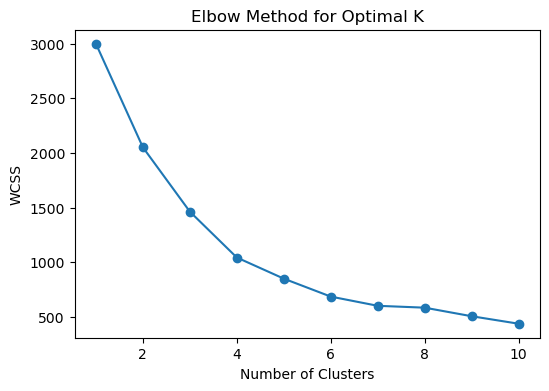

In [9]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

STEP 5: Fit K-Means with K = 4

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df['Cluster'] = clusters
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Cluster
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,3
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0


STEP 6: Understand cluster sizes

In [11]:
df['Cluster'].value_counts()

Cluster
2    286
0    256
3    238
1    220
Name: count, dtype: int64

STEP 7: Analyze cluster characteristics

In [15]:
cluster_summary = df.groupby('Cluster')[['Age', 'Quantity', 'Total Amount']].mean()
cluster_summary

,Age,Quantity,Total Amount
Cluster,,,
0,27.738281,1.703125,204.277344
1,39.118182,3.427273,1359.090909
2,53.580420,1.573427,255.839161
3,43.533613,3.672269,132.500000


## Customer Segments & Insights

- **Cluster 0 (Young Low-Spenders):**
  Younger customers with low purchase quantity and low spending.
  Suitable for discount-based and entry-level product strategies.

- **Cluster 1 (High-Value Customers):**
  Middle-aged customers with high purchase quantity and very high spending.
  This is the most valuable segment and should be targeted with loyalty
  programs and premium offers.

- **Cluster 2 (Older Moderate Spenders):**
  Older customers with moderate spending and lower purchase frequency.
  Trust-based marketing and consistent service can retain this group.

- **Cluster 3 (Frequent Low-Value Buyers):**
  Customers who purchase frequently but spend less per transaction.
  Bundling and upselling strategies can increase their value.


Simple cluster visualization

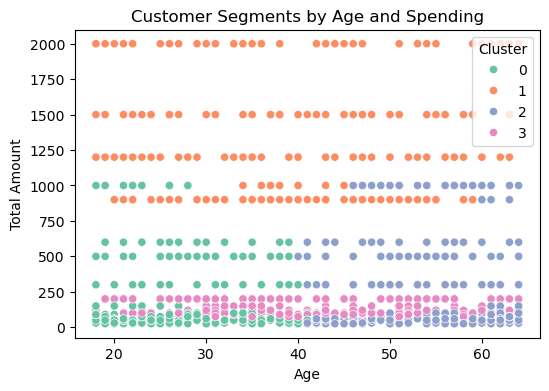

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['Age'],
    y=df['Total Amount'],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title("Customer Segments by Age and Spending")
plt.show()